# Machine Learning Project

##### Title of ML Project: Delivery Time Prediction
##### Name: Farha K Mohammadunny
##### Organization: Entri Elevate
##### Date: 18/03/2026

### 1. Overview
In delivering the food, ordered using Talabat like food delivery applications, predicting the correct time of delivery in advance is a crucial decision. Accurate ETA predictions improve customer satisfaction, optimize driver allocation, and enable better surge pricing decisions.

### 2. Objective
To develop an accurate and efficient machine learning model that predicts delivery duration in minutes for food orders.

### 3. Data Description
- Source: talabat_enhanced_orders.csv from https://www.kaggle.com/datasets/waddahali/order-delivery-dataset/data
- Features:
    1. Order_ID : Unique order Id
    2. User_ID : User Id
    3. Restaurant_ID : Restuarant Id
    4. Driver_ID : Driver Id
    5. Item_Name : Name of the item ordered
    6. Quantity : Quantity of the item ordered
    7. Total_Price : Total bill amount
    8. Order_Time : Time which the order is placed
    9. Delivery_Time : Time the order is delivered
    10. City : Place from where the order is placed
    11. Payment_Method : Payment method
    12. Order_Status : Status of the order
    13. Driver_Vehicle : Type of the vehicle used by the driver to deliver
    14. Restaurant_Lat : Latitude of the restuarant
    15. Restaurant_Lon : Longitude of the restuarant
    16. Customer_Lat : Latitude of the customer
    17. Customer_Lon : Longitude of the customer
    18. Driver_Lat : Latitude of the driver
    19. Driver_Lon : Longitude of the driver
    20. Delivery_Distance_km : Delivery distance in Kilometer
    21. Traffic_Level : Level of Traffic
    22. Driver_Availability : Availability of the driver
- Target Variable:
  Delivery_Duration_Minutes : Delivery duration in minutes

In [1]:
# Import nessesary libraries.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import xgboost as xgb
except ImportError:
    ! pip install xgboost -q
    import xgboost as xgb

#### Load Data

In [2]:
df = pd.read_csv('talabat_enhanced_orders.csv')
df.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,...,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,...,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,...,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


In [3]:
df.tail()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
99995,99996,U7615,524,131,Sushi,2,76.54,2025-06-16 08:04:00,2025-06-16 08:59:00,55,...,Car,30.599392,31.506886,30.571412,31.512006,30.594321,31.508916,3.140535,High,Online
99996,99997,U2671,459,450,Shawarma,2,86.50,2025-06-13 12:13:00,2025-06-13 12:43:00,30,...,Car,30.598870,31.507169,30.592725,31.492901,30.607278,31.501169,1.528541,Medium,Online
99997,99998,U2735,12,88,Fried Chicken,4,165.60,2025-06-02 22:51:00,2025-06-02 23:33:00,42,...,Bicycle,30.594678,31.489688,30.592766,31.505024,30.587210,31.510486,1.485960,Low,Online
99998,99999,U7356,570,473,Koshary,4,199.84,2025-06-11 06:09:00,2025-06-11 06:49:00,40,...,Bicycle,30.786478,31.004323,30.768406,31.013934,30.793099,31.016429,2.204660,Low,Offline
99999,100000,U3960,790,283,Koshary,5,235.30,2025-06-14 23:01:00,2025-06-14 23:48:00,47,...,Motorbike,31.033496,31.361562,31.046063,31.381597,31.042967,31.387703,2.366264,Low,Online


In [4]:
df.shape

(100000, 23)

In [5]:
df.columns

Index(['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID', 'Item_Name',
       'Quantity', 'Total_Price', 'Order_Time', 'Delivery_Time',
       'Delivery_Duration_Minutes', 'City', 'Payment_Method', 'Order_Status',
       'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat',
       'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km',
       'Traffic_Level', 'Driver_Availability'],
      dtype='object')

### 4. Data Preprocessing & Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Order_ID                   100000 non-null  int64  
 1   User_ID                    100000 non-null  object 
 2   Restaurant_ID              100000 non-null  int64  
 3   Driver_ID                  100000 non-null  int64  
 4   Item_Name                  100000 non-null  object 
 5   Quantity                   100000 non-null  int64  
 6   Total_Price                100000 non-null  float64
 7   Order_Time                 100000 non-null  object 
 8   Delivery_Time              100000 non-null  object 
 9   Delivery_Duration_Minutes  100000 non-null  int64  
 10  City                       100000 non-null  object 
 11  Payment_Method             100000 non-null  object 
 12  Order_Status               100000 non-null  object 
 13  Driver_Vehicle             100

In [7]:
df.describe()

,Order_ID,Restaurant_ID,Driver_ID,Quantity,Total_Price,Delivery_Duration_Minutes,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,499.832850,250.791800,2.991110,268.925734,37.520110,30.119015,31.063065,30.119060,31.062971,30.119075,31.062993,2.165303
std,28867.657797,288.255257,144.289418,1.410132,170.490396,10.060876,1.271638,0.487754,1.271674,0.487811,1.271699,0.487826,1.038473
min,1.000000,1.000000,1.000000,1.000000,30.000000,15.000000,27.160900,29.898701,27.160900,29.898706,27.160901,29.898703,0.008839
25%,25000.750000,250.000000,126.000000,2.000000,129.430000,30.000000,30.023110,31.008774,30.023370,31.008460,30.023295,31.008410,1.355602
50%,50000.500000,499.000000,251.000000,3.000000,233.200000,38.000000,30.587306,31.209099,30.587054,31.208817,30.587085,31.209075,2.122694
75%,75000.250000,750.000000,376.000000,4.000000,381.510000,45.000000,31.026912,31.371676,31.027112,31.371856,31.027241,31.371508,2.924525
max,100000.000000,1000.000000,500.000000,5.000000,750.000000,60.000000,31.220099,31.521997,31.220096,31.521995,31.220099,31.521999,5.597928


In [8]:
df[df.duplicated()]

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability


In [9]:
df.isnull().sum()

Order_ID                     0
User_ID                      0
Restaurant_ID                0
Driver_ID                    0
Item_Name                    0
Quantity                     0
Total_Price                  0
Order_Time                   0
Delivery_Time                0
Delivery_Duration_Minutes    0
City                         0
Payment_Method               0
Order_Status                 0
Driver_Vehicle               0
Restaurant_Lat               0
Restaurant_Lon               0
Customer_Lat                 0
Customer_Lon                 0
Driver_Lat                   0
Driver_Lon                   0
Delivery_Distance_km         0
Traffic_Level                0
Driver_Availability          0
dtype: int64

##### Initial Observation:
Dataset contains 100000 rows and 23 columns.
No missing values in any columns. No duplicated rows.
There are non numerical data, so encoding will be required.
Also there are some unrelevent columns for the delivery time prediction which can be removed.

### Feature Selection

In [10]:
df = df.drop(columns=['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID',
                      'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat',
                      'Customer_Lon', 'Driver_Lat', 'Driver_Lon',
                      'Order_Time', 'Delivery_Time'])

In [11]:
df.head()

,Item_Name,Quantity,Total_Price,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,Fried Chicken,3,273.72,39,Alexandria,Wallet,Delivered,Motorbike,1.666106,High,Offline
1,Sandwich,3,365.82,33,Zagazig,Credit Card,Delivered,Motorbike,2.738698,Low,Online
2,Koshary,3,401.94,38,Assiut,Cash,In Transit,Car,2.929079,Medium,Online
3,Sushi,2,221.18,52,Mansoura,Cash,Delivered,Car,0.677498,Low,Online
4,Koshary,5,355.55,44,Mansoura,Wallet,Delivered,Motorbike,1.994769,High,Online


In [12]:
df.columns

Index(['Item_Name', 'Quantity', 'Total_Price', 'Delivery_Duration_Minutes',
       'City', 'Payment_Method', 'Order_Status', 'Driver_Vehicle',
       'Delivery_Distance_km', 'Traffic_Level', 'Driver_Availability'],
      dtype='object')

### Handling Outliers

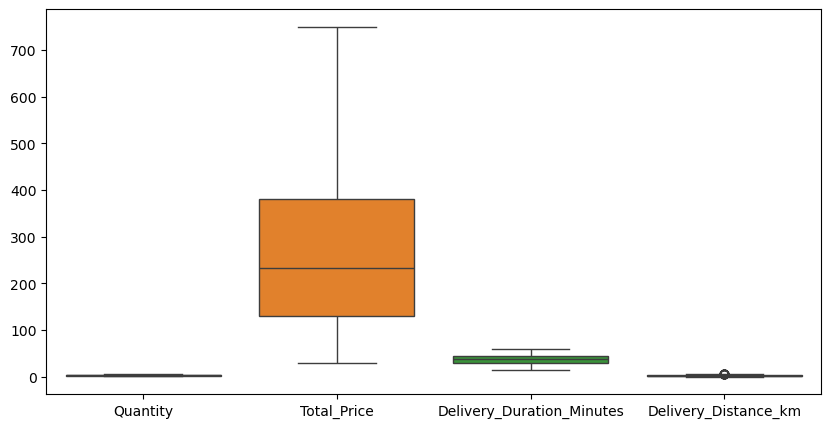

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(df)
plt.show()

<Axes: ylabel='Delivery_Distance_km'>

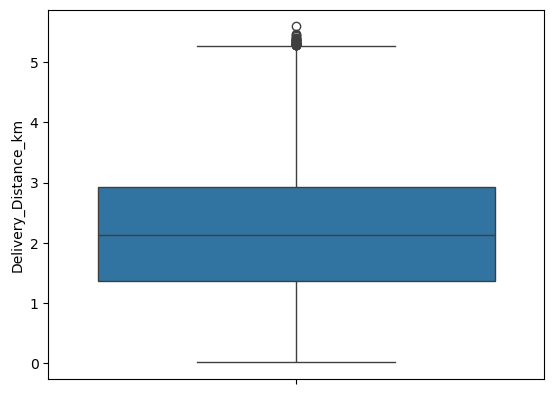

In [14]:
sns.boxplot(data = df['Delivery_Distance_km'])

There is outliers in 'Delivery_Distance_km' column.

In [15]:
outlier_column = ['Delivery_Distance_km']

In [16]:
def remove_outliers_iqr(data, column):
    q1, q2, q3 = np.percentile(data[column], [25, 50, 75])
    print("q1, q2, q3 : ", q1, q2, q3)
    IQR = q3 - q1
    print("IQR : ", IQR)
    lower_limit = q1 - (1.5 * IQR)
    upper_limit = q3 + (1.5 * IQR)
    data[column] = np.where(data[column] > upper_limit, upper_limit, data[column]) # Capping the upper limit
    data[column] = np.where(data[column] < lower_limit, lower_limit, data[column]) # Flooring the lower limit

In [17]:
for column in outlier_column:
    remove_outliers_iqr(df, column)

q1, q2, q3 :  1.355602253703684 2.1226941935773773 2.9245245379916684
IQR :  1.5689222842879844


<Axes: ylabel='Delivery_Distance_km'>

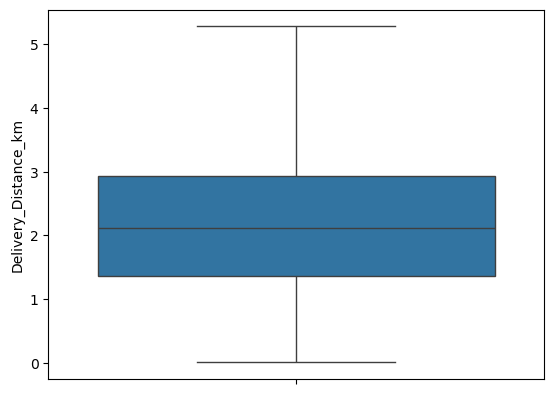

In [18]:
sns.boxplot(data = df['Delivery_Distance_km'])

Outliers are removed.

### 5. Exploratory Data Analysis (EDA)

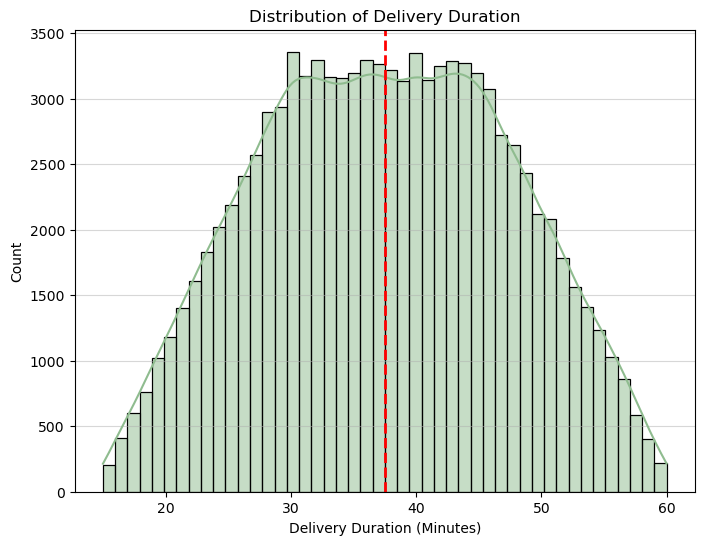

In [19]:
plt.figure(figsize = (8, 6))
sns.histplot(df['Delivery_Duration_Minutes'], kde=True, bins = 46, color = 'darkseagreen', edgecolor = 'black')
plt.axvline(df['Delivery_Duration_Minutes'].mean(), color='red', linestyle='--', lw=2, label=f"Mean: {df['Delivery_Duration_Minutes'].mean():.1f} min")

plt.xlabel('Delivery Duration (Minutes)')
plt.ylabel('Count')
plt.title('Distribution of Delivery Duration')
plt.grid(axis = 'y', linestyle = '-', alpha = 0.5)
plt.show()

**Insights:**

*   **Frequency**: Shows the frequency distribution of `Delivery_Duration_Minutes`.
*   **KDE Overlay**: `kde=True` adds a smooth density curve.
*   **Bins**: Divides the data into 46 bins (`bins=46`).

From the above histogram we can see that for the delivery minimum 15 minutes to maximum of 60 minutes is taking with an average of 37 minutes and have a normal distribution.

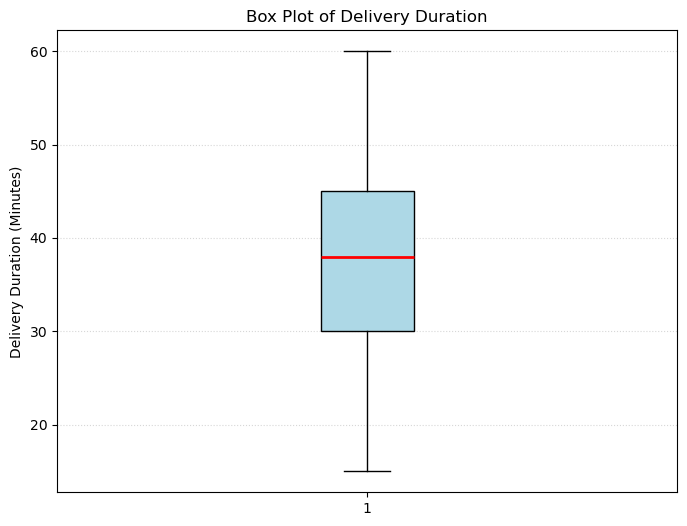

In [20]:
plt.figure(figsize = (8, 6))
plt.boxplot(df['Delivery_Duration_Minutes'], vert=True, patch_artist=True,
            boxprops={'facecolor': 'lightblue'},
            medianprops={'color': 'red', 'linewidth': 2})

plt.ylabel('Delivery Duration (Minutes)')
plt.title('Box Plot of Delivery Duration')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.show()

##### Delivery Duration by Categorical Features

In [21]:
cat_columns = ['Item_Name', 'City', 'Payment_Method', 'Order_Status', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability']

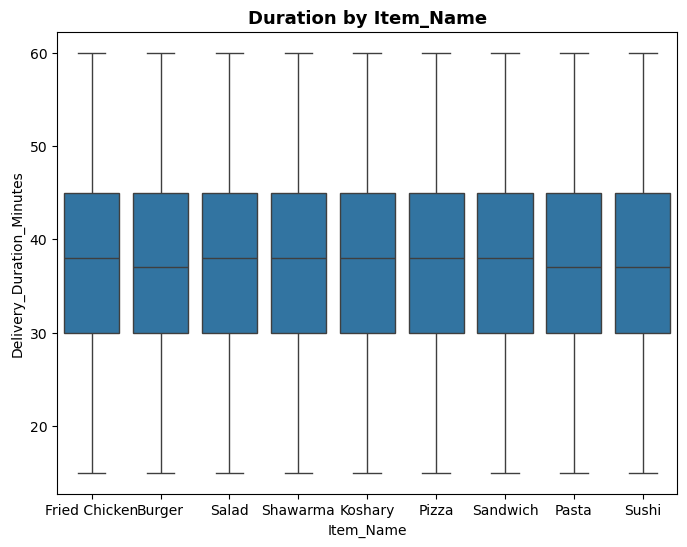

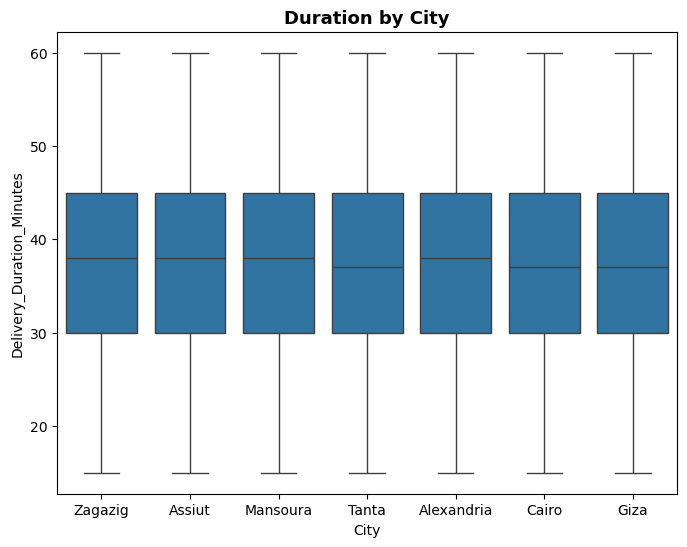

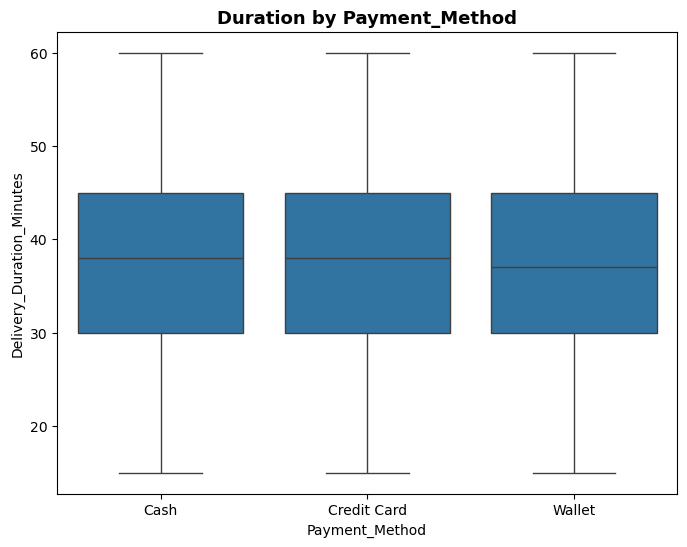

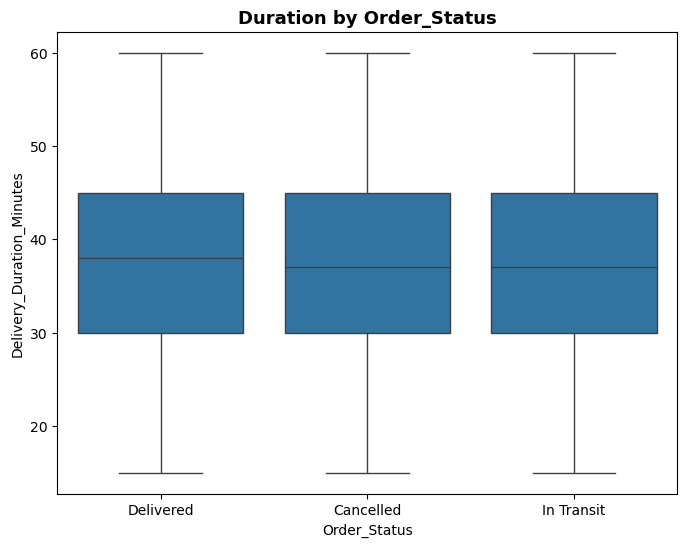

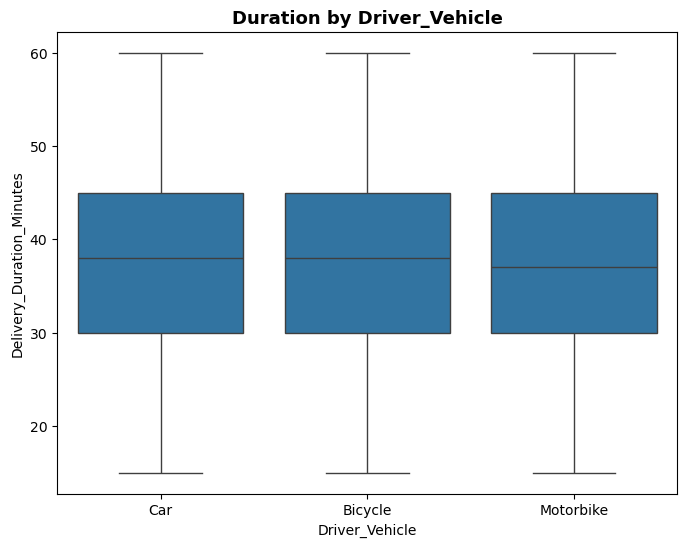

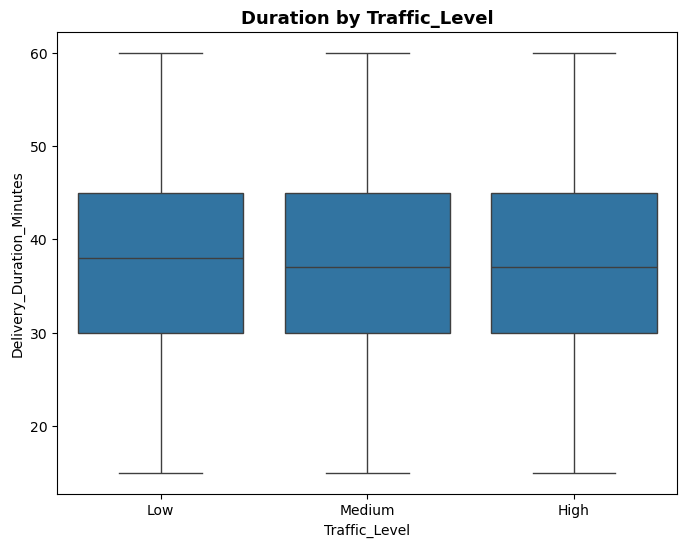

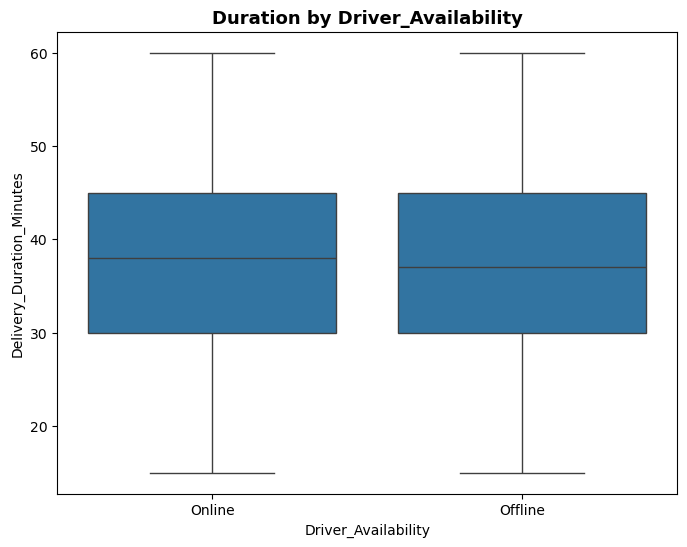

In [22]:
for col in cat_columns:
    order = df.groupby(col)['Delivery_Duration_Minutes'].mean().sort_values(ascending = False).index
    plt.figure(figsize = (8, 6))
    sns.boxplot(data = df, x = col, y = 'Delivery_Duration_Minutes', order = order)
    plt.title(f'Duration by {col}', fontsize=13, fontweight='bold')
    plt.show()

**Insights:**

*   **Distribution**: Shows the distribution of `Delivery_Duration_Minutes` by various categorical features.
*   **Components**: Displays the median (line), IQR (box), and range (whiskers).

Target status : min = 15mints, max = 60mints, Q1 = 30, Q3 = 45
For almost all data median lies between 35 - 38 minutes.

#### Correlation Matrix

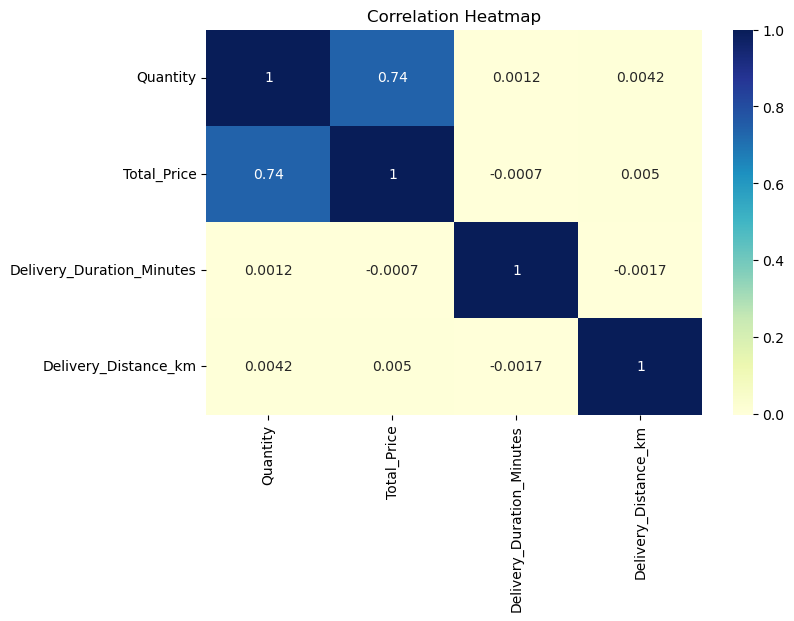

In [23]:
plt.figure(figsize = (8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.title("Correlation Heatmap")
plt.show()

Correlations with Delivery_Duration_Minutes:
* Quantity = 0.0012
* Total_Price = -0.0007
* Delivery_Distance_km = -0.0017

Avoids multicollinearity

### 6. Feature Engineering

### Encoding

In [24]:
df.dtypes

Item_Name                     object
Quantity                       int64
Total_Price                  float64
Delivery_Duration_Minutes      int64
City                          object
Payment_Method                object
Order_Status                  object
Driver_Vehicle                object
Delivery_Distance_km         float64
Traffic_Level                 object
Driver_Availability           object
dtype: object

**Label Encoding the Item_Name**

In [25]:
df['Item_Name'].unique()

array(['Fried Chicken', 'Sandwich', 'Koshary', 'Sushi', 'Shawarma',
       'Pizza', 'Burger', 'Salad', 'Pasta'], dtype=object)

In [26]:
le_Item_Name = LabelEncoder()
df['Item_Name'] = le_Item_Name.fit_transform(df['Item_Name'])
df

,Item_Name,Quantity,Total_Price,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,3,273.72,39,Alexandria,Wallet,Delivered,Motorbike,1.666106,High,Offline
1,6,3,365.82,33,Zagazig,Credit Card,Delivered,Motorbike,2.738698,Low,Online
2,2,3,401.94,38,Assiut,Cash,In Transit,Car,2.929079,Medium,Online
3,8,2,221.18,52,Mansoura,Cash,Delivered,Car,0.677498,Low,Online
4,2,5,355.55,44,Mansoura,Wallet,Delivered,Motorbike,1.994769,High,Online
...,...,...,...,...,...,...,...,...,...,...,...
99995,8,2,76.54,55,Zagazig,Wallet,Delivered,Car,3.140535,High,Online
99996,7,2,86.50,30,Zagazig,Credit Card,Delivered,Car,1.528541,Medium,Online
99997,1,4,165.60,42,Zagazig,Credit Card,Delivered,Bicycle,1.485960,Low,Online
99998,2,4,199.84,40,Tanta,Wallet,In Transit,Bicycle,2.204660,Low,Offline


In [27]:
df['Item_Name'].unique()

array([1, 6, 2, 8, 7, 4, 0, 5, 3])

**Label Encoding the City**

In [28]:
df['City'].unique()

array(['Alexandria', 'Zagazig', 'Assiut', 'Mansoura', 'Cairo', 'Tanta',
       'Giza'], dtype=object)

In [29]:
le_City = LabelEncoder()
df['City'] = le_City.fit_transform(df['City'])
df

,Item_Name,Quantity,Total_Price,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,3,273.72,39,0,Wallet,Delivered,Motorbike,1.666106,High,Offline
1,6,3,365.82,33,6,Credit Card,Delivered,Motorbike,2.738698,Low,Online
2,2,3,401.94,38,1,Cash,In Transit,Car,2.929079,Medium,Online
3,8,2,221.18,52,4,Cash,Delivered,Car,0.677498,Low,Online
4,2,5,355.55,44,4,Wallet,Delivered,Motorbike,1.994769,High,Online
...,...,...,...,...,...,...,...,...,...,...,...
99995,8,2,76.54,55,6,Wallet,Delivered,Car,3.140535,High,Online
99996,7,2,86.50,30,6,Credit Card,Delivered,Car,1.528541,Medium,Online
99997,1,4,165.60,42,6,Credit Card,Delivered,Bicycle,1.485960,Low,Online
99998,2,4,199.84,40,5,Wallet,In Transit,Bicycle,2.204660,Low,Offline


In [30]:
df['City'].unique()

array([0, 6, 1, 4, 2, 5, 3])

**Label Encoding the Driver_Vehicle**

In [31]:
df['Driver_Vehicle'].unique()

array(['Motorbike', 'Car', 'Bicycle'], dtype=object)

In [32]:
le_Driver_Vehicle = LabelEncoder()
df['Driver_Vehicle'] = le_Driver_Vehicle.fit_transform(df['Driver_Vehicle'])
df

,Item_Name,Quantity,Total_Price,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,3,273.72,39,0,Wallet,Delivered,2,1.666106,High,Offline
1,6,3,365.82,33,6,Credit Card,Delivered,2,2.738698,Low,Online
2,2,3,401.94,38,1,Cash,In Transit,1,2.929079,Medium,Online
3,8,2,221.18,52,4,Cash,Delivered,1,0.677498,Low,Online
4,2,5,355.55,44,4,Wallet,Delivered,2,1.994769,High,Online
...,...,...,...,...,...,...,...,...,...,...,...
99995,8,2,76.54,55,6,Wallet,Delivered,1,3.140535,High,Online
99996,7,2,86.50,30,6,Credit Card,Delivered,1,1.528541,Medium,Online
99997,1,4,165.60,42,6,Credit Card,Delivered,0,1.485960,Low,Online
99998,2,4,199.84,40,5,Wallet,In Transit,0,2.204660,Low,Offline


In [33]:
df['Driver_Vehicle'].unique()

array([2, 1, 0])

**Ordinal Encoding the Traffic_Level**

In [34]:
df['Traffic_Level'].unique()

array(['High', 'Low', 'Medium'], dtype=object)

In [35]:
traffic_level_map = {'High' : 0, 'Low' : 1, 'Medium' : 2}
df['Traffic_Level'] = df['Traffic_Level'].map(traffic_level_map)

In [36]:
df['Traffic_Level'].unique()

array([0, 1, 2])

**Ordinal Encoding the Payment_Method**

In [37]:
df['Payment_Method'].unique()

array(['Wallet', 'Credit Card', 'Cash'], dtype=object)

In [38]:
payment_method_map = {'Wallet' : 0, 'Credit Card' : 1, 'Cash' : 2}
df['Payment_Method'] = df['Payment_Method'].map(payment_method_map)

In [39]:
df

,Item_Name,Quantity,Total_Price,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,3,273.72,39,0,0,Delivered,2,1.666106,0,Offline
1,6,3,365.82,33,6,1,Delivered,2,2.738698,1,Online
2,2,3,401.94,38,1,2,In Transit,1,2.929079,2,Online
3,8,2,221.18,52,4,2,Delivered,1,0.677498,1,Online
4,2,5,355.55,44,4,0,Delivered,2,1.994769,0,Online
...,...,...,...,...,...,...,...,...,...,...,...
99995,8,2,76.54,55,6,0,Delivered,1,3.140535,0,Online
99996,7,2,86.50,30,6,1,Delivered,1,1.528541,2,Online
99997,1,4,165.60,42,6,1,Delivered,0,1.485960,1,Online
99998,2,4,199.84,40,5,0,In Transit,0,2.204660,1,Offline


**Ordinal Encoding the Order_Status**

In [40]:
df['Order_Status'].unique()

array(['Delivered', 'In Transit', 'Cancelled'], dtype=object)

In [41]:
order_status_map = {'Delivered' : 0, 'In Transit' : 1, 'Cancelled' : 2}
df['Order_Status'] = df['Order_Status'].map(order_status_map)
df

,Item_Name,Quantity,Total_Price,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,3,273.72,39,0,0,0,2,1.666106,0,Offline
1,6,3,365.82,33,6,1,0,2,2.738698,1,Online
2,2,3,401.94,38,1,2,1,1,2.929079,2,Online
3,8,2,221.18,52,4,2,0,1,0.677498,1,Online
4,2,5,355.55,44,4,0,0,2,1.994769,0,Online
...,...,...,...,...,...,...,...,...,...,...,...
99995,8,2,76.54,55,6,0,0,1,3.140535,0,Online
99996,7,2,86.50,30,6,1,0,1,1.528541,2,Online
99997,1,4,165.60,42,6,1,0,0,1.485960,1,Online
99998,2,4,199.84,40,5,0,1,0,2.204660,1,Offline


**One-hot Encoding the Driver_Availability**

In [42]:
df['Driver_Availability'].unique()

array(['Offline', 'Online'], dtype=object)

In [43]:
df = pd.get_dummies(df, columns=['Driver_Availability'], drop_first=True, dtype=int)

In [44]:
df

,Item_Name,Quantity,Total_Price,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Delivery_Distance_km,Traffic_Level,Driver_Availability_Online
0,1,3,273.72,39,0,0,0,2,1.666106,0,0
1,6,3,365.82,33,6,1,0,2,2.738698,1,1
2,2,3,401.94,38,1,2,1,1,2.929079,2,1
3,8,2,221.18,52,4,2,0,1,0.677498,1,1
4,2,5,355.55,44,4,0,0,2,1.994769,0,1
...,...,...,...,...,...,...,...,...,...,...,...
99995,8,2,76.54,55,6,0,0,1,3.140535,0,1
99996,7,2,86.50,30,6,1,0,1,1.528541,2,1
99997,1,4,165.60,42,6,1,0,0,1.485960,1,1
99998,2,4,199.84,40,5,0,1,0,2.204660,1,0


In [45]:
df.dtypes

Item_Name                       int64
Quantity                        int64
Total_Price                   float64
Delivery_Duration_Minutes       int64
City                            int64
Payment_Method                  int64
Order_Status                    int64
Driver_Vehicle                  int64
Delivery_Distance_km          float64
Traffic_Level                   int64
Driver_Availability_Online      int64
dtype: object

### 7. Feature Scaling

In [46]:
x = df.drop('Delivery_Duration_Minutes', axis = 1)
y = df['Delivery_Duration_Minutes']

In [47]:
x

,Item_Name,Quantity,Total_Price,City,Payment_Method,Order_Status,Driver_Vehicle,Delivery_Distance_km,Traffic_Level,Driver_Availability_Online
0,1,3,273.72,0,0,0,2,1.666106,0,0
1,6,3,365.82,6,1,0,2,2.738698,1,1
2,2,3,401.94,1,2,1,1,2.929079,2,1
3,8,2,221.18,4,2,0,1,0.677498,1,1
4,2,5,355.55,4,0,0,2,1.994769,0,1
...,...,...,...,...,...,...,...,...,...,...
99995,8,2,76.54,6,0,0,1,3.140535,0,1
99996,7,2,86.50,6,1,0,1,1.528541,2,1
99997,1,4,165.60,6,1,0,0,1.485960,1,1
99998,2,4,199.84,5,0,1,0,2.204660,1,0


In [48]:
y

0        39
1        33
2        38
3        52
4        44
         ..
99995    55
99996    30
99997    42
99998    40
99999    47
Name: Delivery_Duration_Minutes, Length: 100000, dtype: int64

In [49]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [50]:
x

array([[-1.16126645,  0.00630441,  0.02812059, ..., -0.48071507,
        -1.30287109, -3.01864969],
       [ 0.77508126,  0.00630441,  0.56832967, ...,  0.55220976,
         0.0580572 ,  0.33127395],
       [-0.7739969 ,  0.00630441,  0.78019017, ...,  0.7355503 ,
         1.41898549,  0.33127395],
       ...,
       [-1.16126645,  0.71546167, -0.6060532 , ..., -0.65419966,
         0.0580572 ,  0.33127395],
       [-0.7739969 ,  0.71546167, -0.40521977, ...,  0.03792168,
         0.0580572 , -3.01864969],
       [-0.7739969 ,  1.42461894, -0.19723047, ...,  0.19354967,
         0.0580572 ,  0.33127395]], shape=(100000, 10))

In [51]:
x = pd.DataFrame(x)
x.head()

,0,1,2,3,4,5,6,7,8,9
0,-1.161266,0.006304,0.028121,-1.501754,-1.227133,-0.398366,1.226823,-0.480715,-1.302871,-3.018650
1,0.775081,0.006304,0.568330,1.493328,-0.003402,-0.398366,1.226823,0.552210,0.058057,0.331274
2,-0.773997,0.006304,0.780190,-1.002574,1.220329,1.220020,0.001813,0.735550,1.418985,0.331274
3,1.549620,-0.702853,-0.280051,0.494967,1.220329,-0.398366,0.001813,-1.432763,0.058057,0.331274
4,-0.773997,1.424619,0.508091,0.494967,-1.227133,-0.398366,1.226823,-0.164207,-1.302871,0.331274


### 8. Model Building &
### 9. Model Evaluation

**Train-Test Split**

In [52]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

**Model Training & Comparison**

In [53]:
def train_evaluation_model(model, x_train, y_train, x_test, y_test, name):
    # Train Model
    model.fit(x_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluate Performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f'MAE        : {mae:.4f}')
    print(f'RMSE       : {rmse:.4f}')
    print(f'R-squared  : {r2:.4f}')
   
    # Check for over fitting and under fitting and predict on both training and test sets.
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    print(f'Train R2 Score      : {r2_train:.4f}')
    print(f'Test R2 Score       : {r2_test:.4f}')

    # Visualization: Actual vs Predicted
    plt.figure(figsize = (8, 6))
    sns.scatterplot(x = y_test, y = y_pred)
    plt.xlabel("Actual Delivery Time")
    plt.ylabel("Predicted Delivery Time")
    plt.title("Actual vs Predicted Delivery Time")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.show()

##### Linear Regression

MAE        : 8.4231
RMSE       : 10.0466
R-squared  : 0.0000
Train R2 Score      : 0.0001
Test R2 Score       : 0.0000


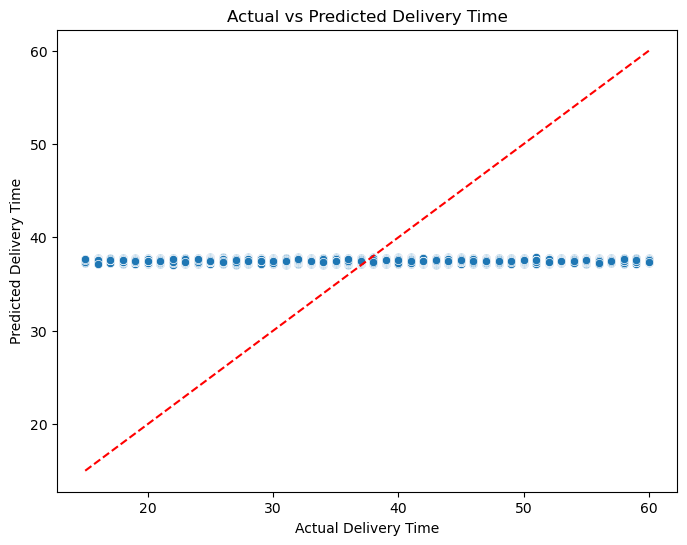

In [54]:
lr_model = LinearRegression()
train_evaluation_model(lr_model, X_train, y_train, X_test, y_test, 'Linear Regression')

##### Polynomial Regression

MAE        : 8.4231
RMSE       : 10.0466
R-squared  : 0.0000
Train R2 Score      : 0.0001
Test R2 Score       : 0.0000


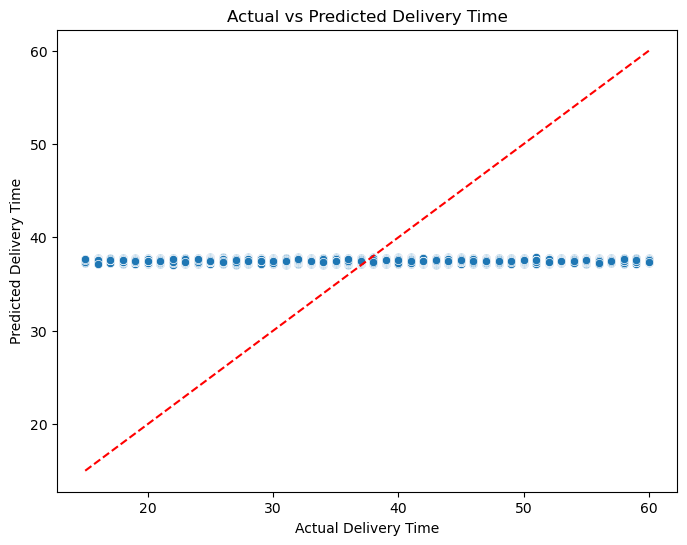

In [55]:
# Apply polynomial transformation (degree 2)
poly = PolynomialFeatures(degree = 2, include_bias = False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Fit polynomial regression model
poly_model = LinearRegression()
train_evaluation_model(poly_model, X_train, y_train, X_test, y_test, 'Polynomial Regression')

##### DecisionTreeRegressor

MAE        : 11.7460
RMSE       : 14.4797
R-squared  : -1.0772
Train R2 Score      : 1.0000
Test R2 Score       : -1.0772


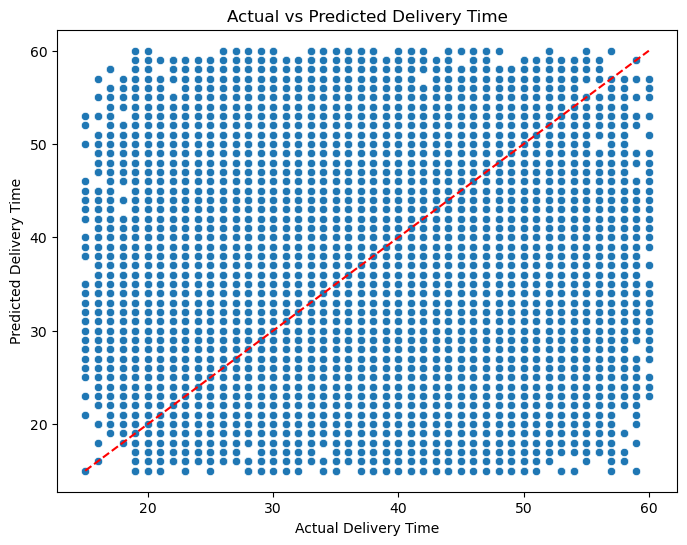

In [56]:
dtr = DecisionTreeRegressor()
train_evaluation_model(dtr, X_train, y_train, X_test, y_test, 'Decision Tree Regressor')

##### Random Forest Regressor

MAE        : 8.5772
RMSE       : 10.2639
R-squared  : -0.0437
Train R2 Score      : 0.8540
Test R2 Score       : -0.0437


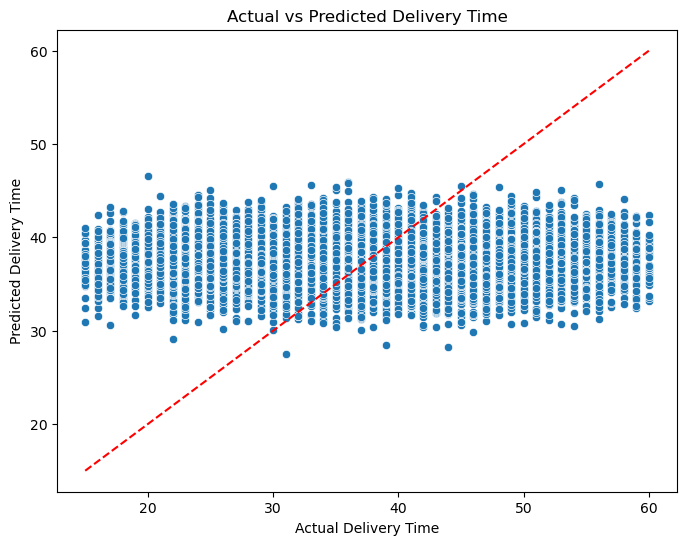

In [57]:
rfr = RandomForestRegressor()
train_evaluation_model(rfr, X_train, y_train, X_test, y_test, 'Random Forest Regressor')

##### Gradient Boosting Regressor

MAE        : 8.4294
RMSE       : 10.0580
R-squared  : -0.0023
Train R2 Score      : 0.0134
Test R2 Score       : -0.0023


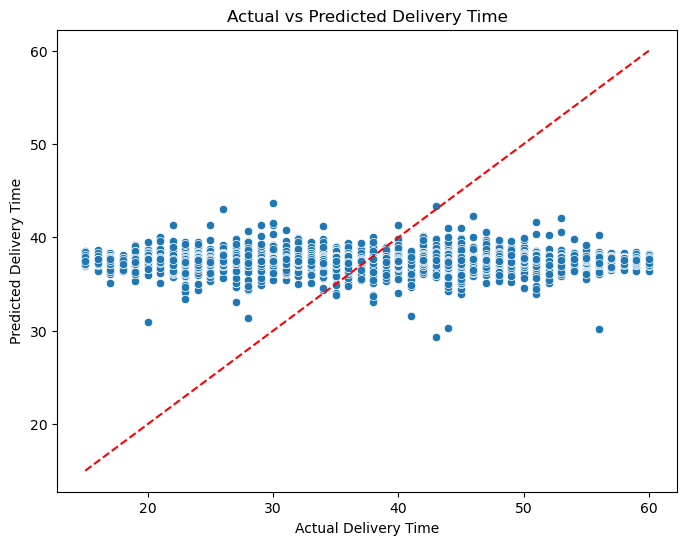

In [58]:
gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
train_evaluation_model(gbr_model, X_train, y_train, X_test, y_test, 'Gradient Boosting Regressor')

##### XGBRegressor

MAE        : 8.5460
RMSE       : 10.2267
R-squared  : -0.0362
Train R2 Score      : 0.2563
Test R2 Score       : -0.0362


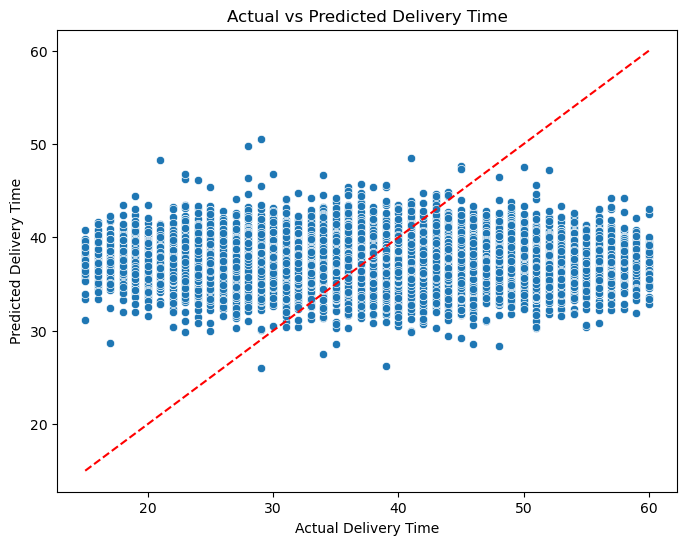

In [59]:
xgb_reg = xgb.XGBRegressor(n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    verbosity=0)
train_evaluation_model(xgb_reg, X_train, y_train, X_test, y_test, 'XGBRegressor')

**Insights**
Delivery Time Prediction model can be developed using XGBoost. While comparing with other model XGBoost hass low mean absolute error and mean squared error and high R-squared value.

If the delivery time is 30 min, then our model predicts 38 or 22 min.
Roughly 8 min up and down.

### 10. Hyperparameter Tuning

In [60]:
param_grid = {'n_estimators': [20, 25, 30], 'max_depth': [5, 7, 9]}

grid_search = GridSearchCV(xgb_reg, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

print("XGBRegressor")
print("Best parameters:", grid_search.best_params_)
print("cross-validation score (negative MSE):", grid_search.best_score_)

XGBRegressor
Best parameters: {'max_depth': 5, 'n_estimators': 20}
cross-validation score (negative MSE): -101.29659881591797


### 12. Model Deployment

In [61]:
# Create a XGB regressor model
model = xgb.XGBRegressor(n_estimators = 20, max_depth = 5)

# Fit the model on the training data
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [62]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae,2))
print("Mean Squared Error (MSE):", round(mse,2))
print("Root Mean Squared Error (RMSE):", round(rmse,2))
print("R-squared (R2) Score:", round(r2,2))

Mean Absolute Error (MAE): 8.44
Mean Squared Error (MSE): 101.36
Root Mean Squared Error (RMSE): 10.07
R-squared (R2) Score: -0.0


In [63]:
# save the model 
#pickle.dump(model, open('model.pkl','wb'))

### 13. Conclusion

Dataset had 100k Talabat food delivery orders, across 7 Egyptian cities. Our target was to find a suitable model which can predict the Delivery_Duration_Minutes accurately. Among the models in Training set, XGBoost is the most performant model to predict delivery duration. Now the model can be used to predict delivery duration in minutes in advance, so that the customer can know how long it will take to recieve the delivery at the time of ordering.

**Possible Improvements**
* Can Integrate whether data for rain / heat conditions.
* Historical average preparation time per restaurant
* Current driver density, active orders in area
* Age of the drivers

### 14. References

https://www.kaggle.com/datasets/waddahali/order-delivery-dataset/data